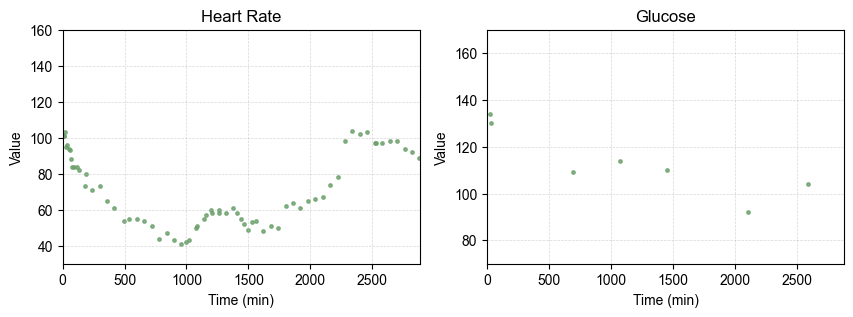

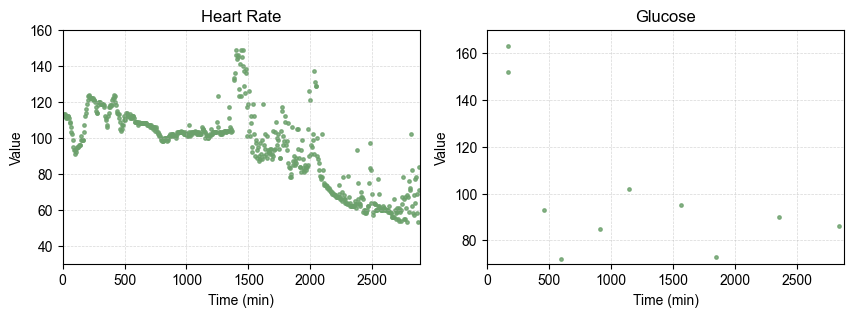

In [ ]:
import os
from math import ceil, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Variable names
# ============================================================
var_names = {
    0: 'gcs',
    1: 'heart_rate',
    2: 'map',
    3: 'resp_rate',
    4: 'temperature',
    5: 'weight',
    6: 'albumin',
    7: 'bilirubin',
    8: 'creatinine',
    9: 'fio2',
    10: 'glucose',
    11: 'hematocrit',
    12: 'lactate',
    13: 'pao2',
    14: 'ph',
    15: 'platelets',
    16: 'sodium',
    17: 'urine',
    18: 'wbc',
    19: 'a10',
    20: 'a_drug',
    21: 'a_supplements',
    22: 'b',
    23: 'c01',
    24: 'c01_etc',
    25: 'c_else',
    26: 'h',
    27: 'l',
    28: 'm',
    29: 'n',
    30: 'r',
    31: 'v',
    32: 'antibiotics',
    33: 'fluid',
    34: 'ventilator',
}

selected_vars = [
    "heart_rate",
    "glucose",

]

FIXED_VAR_YLIMS = {
    "heart_rate": (30.0, 160.0),
    # "map": (35.0, 165.0),
    "glucose": (70.0, 170.0),
    # "lactate": (0.6, 3.5),
}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
def get_fixed_ylim_for_var(var_id, var_names, fixed_var_ylims=None):
    if fixed_var_ylims is None:
        fixed_var_ylims = FIXED_VAR_YLIMS

    raw = var_names.get(var_id, f"var_{var_id}")
    return fixed_var_ylims.get(raw, None)

# ============================================================
# Pretty labels
# ============================================================
PRETTY_VAR_NAMES = {
    "gcs": "GCS",
    "heart_rate": "Heart Rate",
    "map": "MAP",
    "resp_rate": "Respiratory Rate",
    "temperature": "Temperature",
    "weight": "Weight",
    "albumin": "Albumin",
    "bilirubin": "Bilirubin",
    "creatinine": "Creatinine",
    "fio2": "FiO2",
    "glucose": "Glucose",
    "hematocrit": "Hematocrit",
    "lactate": "Lactate",
    "pao2": "PaO2",
    "ph": "pH",
    "platelets": "Platelets",
    "sodium": "Sodium",
    "urine": "Urine",
    "wbc": "WBC",
    "a10": "A10",
    "a_drug": "A Drug",
    "a_supplements": "A Supplements",
    "b": "B",
    "c01": "C01",
    "c01_etc": "C01 Etc",
    "c_else": "C Else",
    "h": "H",
    "l": "L",
    "m": "M",
    "n": "N",
    "r": "R",
    "v": "V",
    "antibiotics": "Antibiotics",
    "fluid": "Fluid",
    "ventilator": "Ventilator",
}


def format_dataset_name(name: str) -> str:
    name = name.lower()
    if name == "mimic":
        return "MIMIC"
    if name == "eicu":
        return "eICU"
    return name


def pretty_var_label_from_id(var_id: int, var_names: dict[int, str]) -> str:
    raw = var_names.get(var_id, f"var_{var_id}")
    return PRETTY_VAR_NAMES.get(raw, raw.replace("_", " ").title())


def invert_var_names(var_names: dict[int, str]) -> dict[str, int]:
    return {v: k for k, v in var_names.items()}


# ============================================================
# Data loading / filtering
# ============================================================
def load_instance_from_feather(
    data_path: str,
    pid: int,
    *,
    var_names: dict[int, str],
    selected_var_names: list[str] | None = None,
) -> pd.DataFrame:
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"File not found: {data_path}")

    df = pd.read_feather(data_path)

    required_cols = {"pid", "itemid", "offset", "value"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{data_path} is missing columns: {missing}")

    df = df[df["pid"] == pid].copy()
    if df.empty:
        raise ValueError(f"pid={pid} not found in {data_path}")

    if selected_var_names is not None:
        inv = invert_var_names(var_names)
        unknown = [v for v in selected_var_names if v not in inv]
        if unknown:
            raise ValueError(f"Unknown variables in selected_var_names: {unknown}")
        selected_ids = [inv[v] for v in selected_var_names]
        df = df[df["itemid"].isin(selected_ids)].copy()

    if df.empty:
        raise ValueError(f"No rows left after variable filtering for pid={pid}")

    df = df.rename(columns={
        "itemid": "varis",
        "offset": "times",
        "value": "values",
    })

    df["pid"] = df["pid"].astype(int)
    df["varis"] = df["varis"].astype(int)
    df["times"] = pd.to_numeric(df["times"], errors="coerce")
    df["values"] = pd.to_numeric(df["values"], errors="coerce")
    df = df.dropna(subset=["times", "values"]).copy()

    df = df.sort_values(["varis", "times"]).reset_index(drop=True)
    return df


# ============================================================
# Plotting
# ============================================================
def plot_instance_data(
    df: pd.DataFrame,
    *,
    dataset_name: str,
    pid: int,
    var_names: dict[int, str],
    time_col: str = "times",
    var_col: str = "varis",
    value_col: str = "values",
    time_unit: str = "min",
    figsize_per_plot: tuple[float, float] = (4.5, 3.2),
    sharey: bool = False,
    use_seaborn: bool = False,
    save_path: str | None = None,
    fixed_var_ylims: dict | None = None,
):
    required = {"pid", time_col, var_col, value_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df missing columns: {missing}")

    dataset_pretty = format_dataset_name(dataset_name)

    uniq_vars = list(df[var_col].drop_duplicates())
    nplots = len(uniq_vars)
    if nplots == 0:
        raise ValueError("No variables to plot.")

    cols = int(ceil(sqrt(nplots)))
    rows_ = int(ceil(nplots / cols))

    if use_seaborn:
        sns.set(style="whitegrid", context="talk")

    fig, axes = plt.subplots(
        rows_,
        cols,
        figsize=(figsize_per_plot[0] * cols, figsize_per_plot[1] * rows_ + 0.7),
        sharey=sharey,
    )

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.reshape(rows_, cols)

    handles, labels = [], []

    for idx, var_id in enumerate(uniq_vars):
        r, c = divmod(idx, cols)
        ax = axes[r, c]

        g = df[df[var_col] == var_id].sort_values(time_col).copy()

        if use_seaborn:
            if len(g) >= 2:
                sns.lineplot(
                    data=g,
                    x=time_col,
                    y=value_col,
                    color="#2D2926",
                    linewidth=1.2,
                    ax=ax,
                    label="Trend",
                    zorder=1,
                )
            sns.scatterplot(
                data=g,
                x=time_col,
                y=value_col,
                color="#ed6f63",
                s=38,
                ax=ax,
                label="Observation",
                zorder=2,
            )
        else:

            ax.scatter(
                g[time_col],
                g[value_col],
                alpha=0.8,
                marker=".", 
                color="#6BA06B",
                s=24,
                zorder=1,
                label="Observation",
            )

        ax.set_title(pretty_var_label_from_id(var_id, var_names), fontsize=22)
        ax.set_xlabel(f"Time ({time_unit})", fontsize=14)
        ax.set_ylabel("Value", fontsize=14)
        ax.set_xlim(0, 2880)
        ylim = get_fixed_ylim_for_var(var_id, var_names, fixed_var_ylims)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)

    for j in range(nplots, rows_ * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")


    fig.tight_layout(rect=[0.02, 0.10, 0.98, 0.94])

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ============================================================
# Run
# ============================================================
base_dir = "./data/split1"

mimic_path = os.path.join(base_dir, "mimic_data_test_1.feather")
eicu_path = os.path.join(base_dir, "eicu_data_test_1.feather")

pid_mimic = 20271349
pid_eicu = 637979

# MIMIC
df_mimic = load_instance_from_feather(
    mimic_path,
    pid_mimic,
    var_names=var_names,
    selected_var_names=selected_vars,
)

plot_instance_data(
    df_mimic,
    dataset_name="mimic",
    pid=pid_mimic,
    var_names=var_names,
    use_seaborn=False,   # True로 바꾸면 seaborn 버전
    save_path="./data/split1/fig_mimic_20271349.png",
    fixed_var_ylims=FIXED_VAR_YLIMS,
)

# eICU
df_eicu = load_instance_from_feather(
    eicu_path,
    pid_eicu,
    var_names=var_names,
    selected_var_names=selected_vars,
)

plot_instance_data(
    df_eicu,
    dataset_name="eicu",
    pid=pid_eicu,
    var_names=var_names,
    use_seaborn=False,   # True로 바꾸면 seaborn 버전
    save_path="./data/split1/fig_eicu_637979.png",
    fixed_var_ylims=FIXED_VAR_YLIMS,
)